<a href="https://colab.research.google.com/github/nahidislam106/Recommendation-System-Backend-API/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Recommendation System

This notebook contains a complete machine learning pipeline for crop recommendation with **enhanced dataset**:
- **12 Features**: Soil nutrients (N, P, K), soil properties (pH, EC), climate conditions (temperature, humidity, weather data, rainfall), and environmental factors (light intensity, air pressure)
- Data Loading and Exploration
- Data Visualization
- Data Preprocessing
- Multiple Model Training (9 Models)
- Model Evaluation and Comparison
- SHAP Analysis for Model Interpretability
- Best Model Selection
- Production-Ready Pipeline

In [1]:
# Option 1: Upload files directly to Colab
# Uncomment the following lines to upload your useable_dataset - useable_dataset.csv file
# from google.colab import files
# uploaded = files.upload()

# Option 2: Mount Google Drive (recommended)
# Uncomment the following lines to mount your Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
#
# After mounting, update the file path in the data loading cell:
# df = pd.read_csv('/content/drive/MyDrive/path_to_your_file/useable_dataset - useable_dataset.csv')

print("Colab setup ready! Choose an option above to load your dataset.")
print("Dataset file: useable_dataset - useable_dataset.csv")

Colab setup ready! Choose an option above to load your dataset.
Dataset file: useable_dataset - useable_dataset.csv


## 🔧 Google Colab Setup

Run this section if using Google Colab to upload your dataset or mount Google Drive.

## 1. Import Libraries

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# SHAP for model interpretability
try:
    import shap
    print("SHAP library loaded successfully!")
except ImportError:
    print("Installing SHAP library...")
    import sys
    !{sys.executable} -m pip install shap
    import shap
    print("SHAP library installed and loaded!")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

SHAP library loaded successfully!
All libraries imported successfully!


## 2. Load and Explore Data

In [3]:
# Load the dataset
df = pd.read_csv('/content/useable_dataset - useable_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (2601, 13)

First few rows:


,N,P,K,temperature,humidity,ph,EC,weather_temperature,weather_humidity,light_intensity,air_pressure,rainfall,crop
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,3.36,20.31,63.72,381.97,997.77,2.64,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,2.25,15.85,73.57,839.16,989.62,16.79,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,3.18,27.10,83.84,946.68,1028.62,23.56,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,2.57,23.20,93.93,660.43,1011.05,8.78,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,1.70,20.57,66.74,510.01,999.20,24.18,rice


### Dataset Features Explanation

This enhanced dataset contains **12 features**:

**Soil Nutrients (3):**
- `N` - Nitrogen content in soil (macro-nutrient)
- `P` - Phosphorus content in soil (macro-nutrient)
- `K` - Potassium content in soil (macro-nutrient)

**Soil Properties (2):**
- `ph` - pH value of the soil (acidity/alkalinity)
- `EC` - Electrical Conductivity (soil salinity indicator)

**Climate Conditions (5):**
- `temperature` - Current temperature (°C)
- `humidity` - Current humidity (%)
- `weather_temperature` - Weather station temperature (°C)
- `weather_humidity` - Weather station humidity (%)
- `rainfall` - Rainfall amount (mm)

**Environmental Factors (2):**
- `light_intensity` - Light intensity measurement
- `air_pressure` - Atmospheric pressure (hPa)

**Target:**
- `crop` - Crop type to be recommended (target variable)

In [4]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nStatistical Summary:")
print(df.describe())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nData Types:")
print(df.dtypes)
print("\n" + "="*50)
print("\nUnique Crops:")
print(df['crop'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2601 entries, 0 to 2600
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   N                    2601 non-null   float64
 1   P                    2601 non-null   float64
 2   K                    2601 non-null   float64
 3   temperature          2601 non-null   float64
 4   humidity             2601 non-null   float64
 5   ph                   2601 non-null   float64
 6   EC                   2601 non-null   float64
 7   weather_temperature  2601 non-null   float64
 8   weather_humidity     2601 non-null   float64
 9   light_intensity      2601 non-null   float64
 10  air_pressure         2601 non-null   float64
 11  rainfall             2601 non-null   float64
 12  crop                 2601 non-null   object 
dtypes: float64(12), object(1)
memory usage: 264.3+ KB
None


Statistical Summary:
                 N            P            K  

## 3. Data Visualization

In [5]:
# Distribution of crop types
fig = px.bar(df['crop'].value_counts().reset_index(),
             x='crop', y='count',
             title='Distribution of Crop Types',
             labels={'crop': 'Crop', 'count': 'Count'},
             color='count',
             color_continuous_scale='viridis')
fig.update_layout(showlegend=False, height=500)
fig.show()

In [7]:
# Distribution of features
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'EC', 'weather_temperature',
            'weather_humidity', 'light_intensity', 'air_pressure', 'rainfall']

fig = make_subplots(rows=2, cols=3, subplot_titles=features)
# Plot first 12 features in a 4x3 grid
fig = make_subplots(rows=4, cols=3, subplot_titles=features)
row_col_positions = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3),
                     (3,1), (3,2), (3,3), (4,1), (4,2), (4,3)]

for i, feature in enumerate(features):
    row, col = row_col_positions[i]
    fig.add_trace(
        go.Histogram(x=df[feature], name=feature, nbinsx=30,
                    marker=dict(color='skyblue', line=dict(color='darkblue', width=1))),
        row=row, col=col
    )


fig.show()
fig.update_layout(height=1000, showlegend=False, title_text="Feature Distributions")

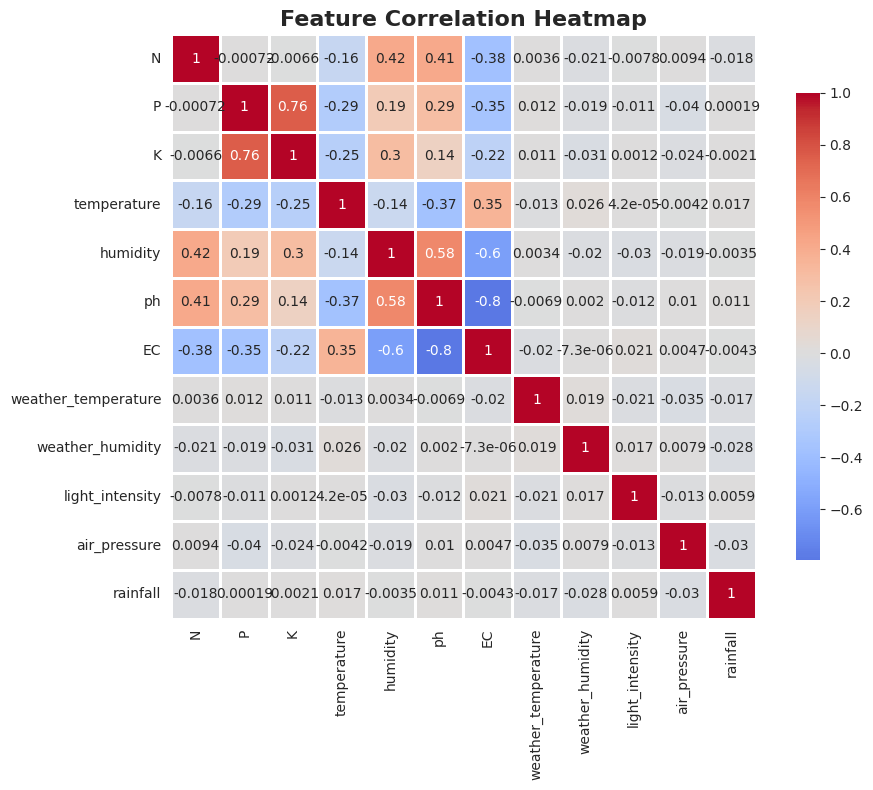

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

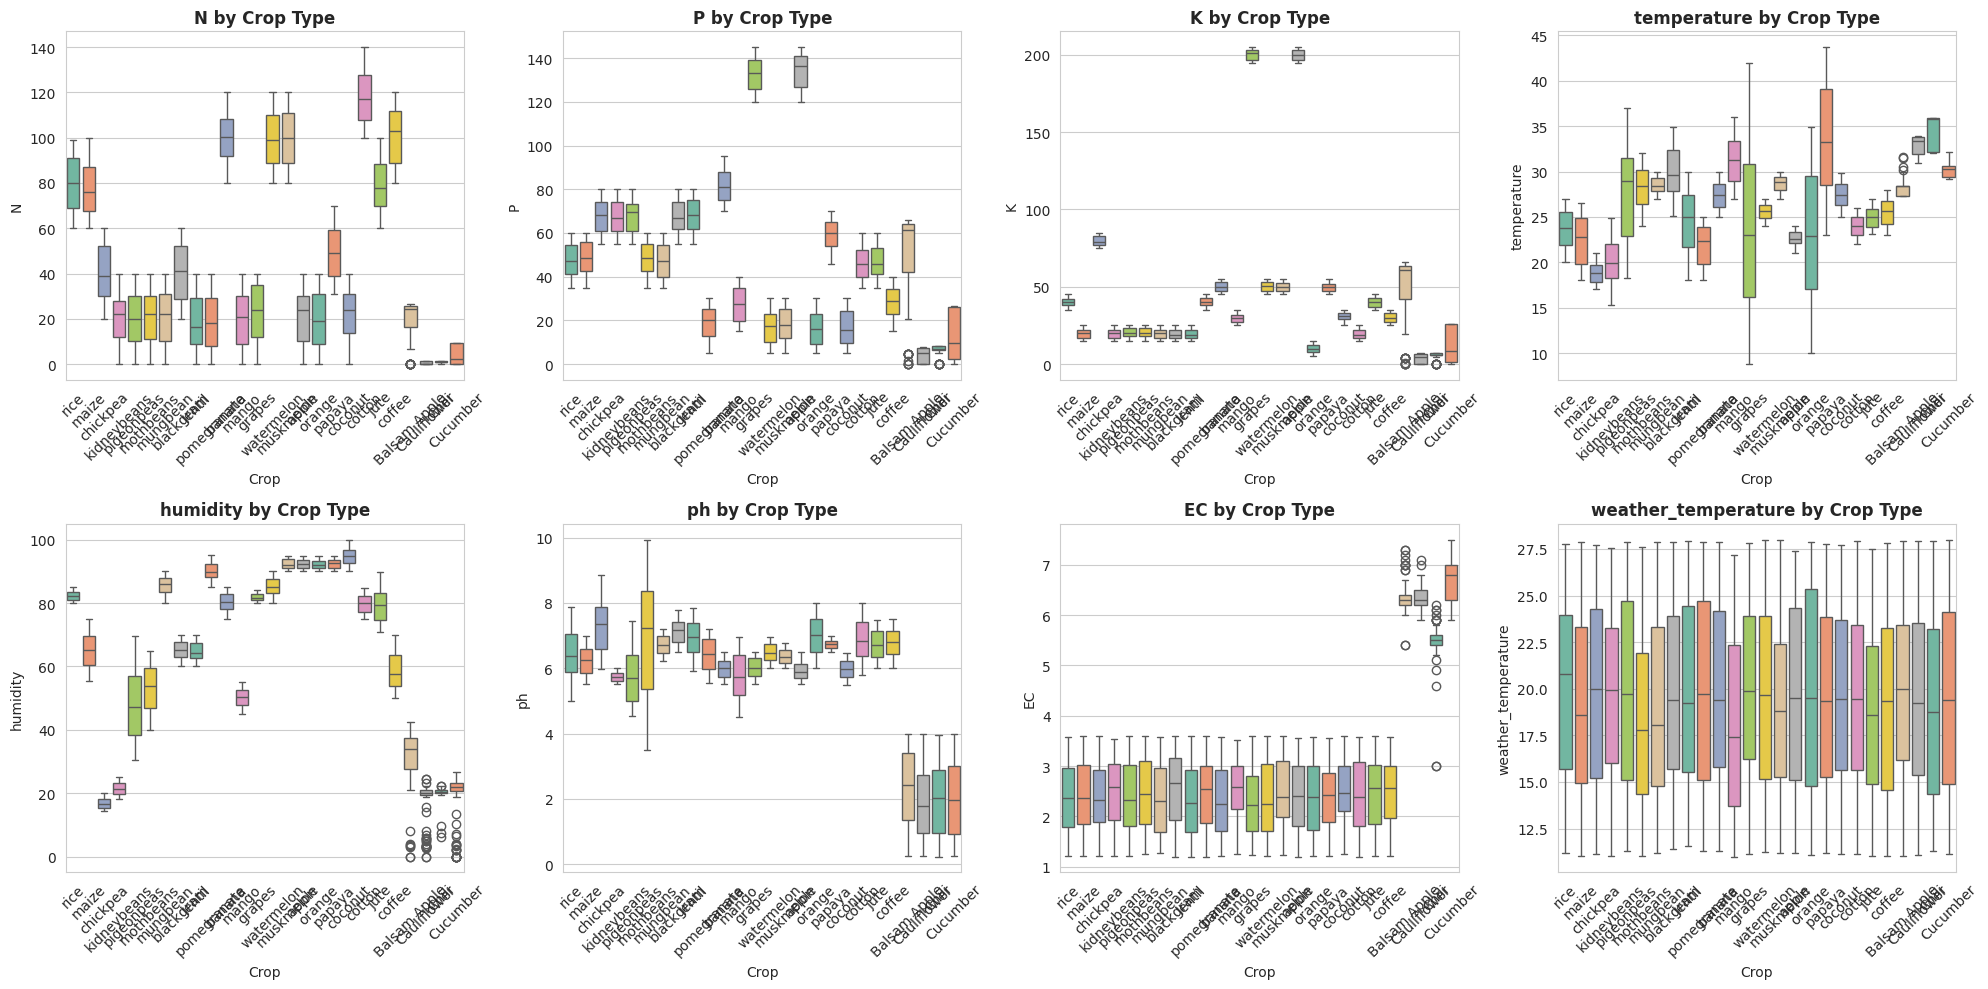

In [9]:
# Box plots for top 8 most important features by crop type
selected_features = features[:8]  # Top 8 features for visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.boxplot(data=df, x='crop', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} by Crop Type', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

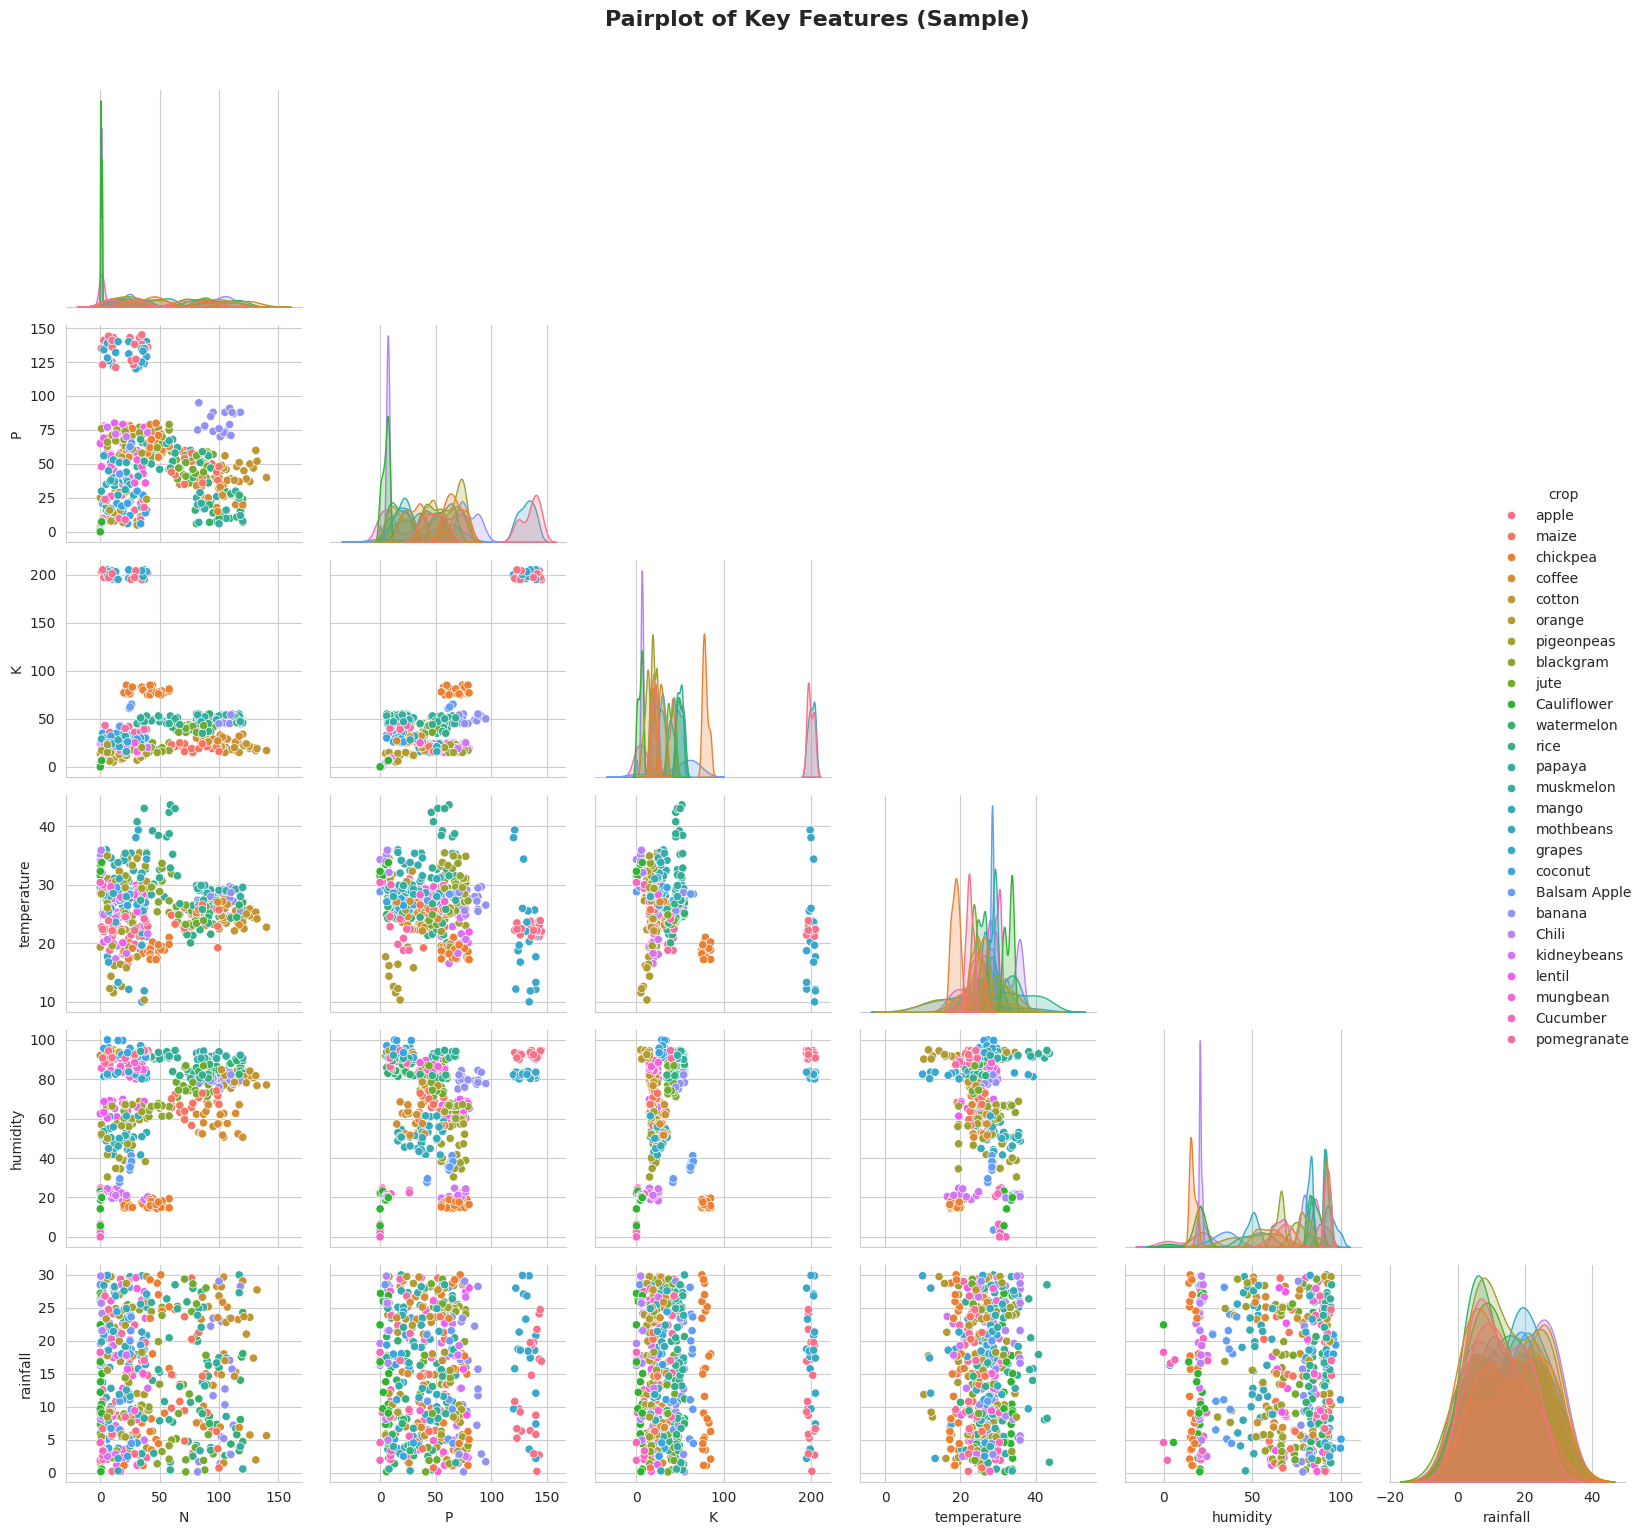

In [11]:
# Pairplot for selected key features (sampling for better visualization)
# Select subset of most relevant features for pairplot
key_features = ['N', 'P', 'K', 'temperature', 'humidity', 'rainfall', 'crop']
sample_df = df[key_features].sample(n=min(500, len(df)), random_state=42)
sns.pairplot(sample_df, hue='crop', diag_kind='kde', corner=True, palette='husl')
plt.suptitle('Pairplot of Key Features (Sample)', y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [12]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Check for outliers using IQR method
def detect_outliers_iqr(data, columns):
    outliers_dict = {}
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_dict[col] = len(outliers)
    return outliers_dict

outliers = detect_outliers_iqr(df, features)
print("\nOutliers detected (using IQR method):")
for feature, count in outliers.items():
    print(f"{feature}: {count} outliers")

Number of duplicate rows: 0

Outliers detected (using IQR method):
N: 0 outliers
P: 122 outliers
K: 200 outliers
temperature: 75 outliers
humidity: 0 outliers
ph: 436 outliers
EC: 368 outliers
weather_temperature: 0 outliers
weather_humidity: 0 outliers
light_intensity: 0 outliers
air_pressure: 0 outliers
rainfall: 0 outliers


In [13]:
# Prepare features and target
X = df[features]
y = df['crop']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget classes: {y.nunique()}")
print(f"Classes: {sorted(y.unique())}")

Features shape: (2601, 12)
Target shape: (2601,)

Target classes: 26
Classes: ['Balsam Apple', 'Cauliflower', 'Chili', 'Cucumber', 'apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [14]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 2080
Testing set size: 521

Training set class distribution:
crop
Chili           81
orange          80
maize           80
pigeonpeas      80
coconut         80
mothbeans       80
banana          80
muskmelon       80
lentil          80
mungbean        80
mango           80
Cucumber        80
rice            80
papaya          80
kidneybeans     80
cotton          80
watermelon      80
Balsam Apple    80
Cauliflower     80
apple           80
pomegranate     80
jute            80
chickpea        80
blackgram       80
grapes          80
coffee          79
Name: count, dtype: int64

Testing set class distribution:
crop
Cucumber        21
jute            20
banana          20
mothbeans       20
cotton          20
muskmelon       20
maize           20
blackgram       20
pomegranate     20
coconut         20
Cauliflower     20
mungbean        20
pigeonpeas      20
kidneybeans     20
apple           20
Chili           20
lentil          20
chickpea        20
orange         

In [15]:
# Feature Scaling - important for models like SVM, KNN, Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"\nOriginal feature means:\n{X_train.mean()}")
print(f"\nScaled feature means (should be close to 0):\n{pd.DataFrame(X_train_scaled, columns=features).mean()}")
print(f"\nScaled feature std (should be close to 1):\n{pd.DataFrame(X_train_scaled, columns=features).std()}")

Features scaled successfully!

Original feature means:
N                        43.636875
P                        47.851346
K                        43.336731
temperature              26.533003
humidity                 63.702208
ph                        5.790075
EC                        3.010356
weather_temperature      19.467091
weather_humidity         71.862577
light_intensity         547.257029
air_pressure           1004.550024
rainfall                 15.046894
dtype: float64

Scaled feature means (should be close to 0):
N                     -9.223391e-17
P                      7.173749e-17
K                      0.000000e+00
temperature            3.258078e-16
humidity               3.176946e-16
ph                    -5.978124e-17
EC                    -4.235928e-16
weather_temperature   -1.392049e-16
weather_humidity      -4.487863e-16
light_intensity        1.366428e-17
air_pressure           1.601283e-15
rainfall               1.503071e-16
dtype: float64

Scaled feature s

## 5. Model Training and Evaluation

We'll train multiple models and compare their performance:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost
6. Support Vector Machine (SVM)
7. K-Nearest Neighbors (KNN)
8. Naive Bayes
9. AdaBoost

In [16]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

print("Models initialized successfully!")
print(f"Total models: {len(models)}")

Models initialized successfully!
Total models: 9


In [18]:
# Train and evaluate all models
results = {}
trained_models = {}

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Training models...\n" + "="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model using encoded target variables
    model.fit(X_train_scaled, y_train_encoded)

    # Make predictions using encoded target variables
    y_pred_encoded = model.predict(X_test_scaled)

    # Calculate metrics using encoded target variables
    accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
    precision = precision_score(y_test_encoded, y_pred_encoded, average='weighted', zero_division=0)
    recall = recall_score(y_test_encoded, y_pred_encoded, average='weighted', zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted', zero_division=0)

    # Cross-validation score using encoded target variables
    cv_scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    }

    # Store trained model
    trained_models[name] = model

    print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, CV: {cv_mean:.4f} (+/- {cv_std:.4f})")

print("\n" + "="*60)
print("All models trained successfully!")

Training models...

Training Logistic Regression...
Logistic Regression - Accuracy: 0.8983, F1-Score: 0.8963, CV: 0.8981 (+/- 0.0185)

Training Decision Tree...
Decision Tree - Accuracy: 0.9520, F1-Score: 0.9518, CV: 0.9428 (+/- 0.0097)

Training Random Forest...
Random Forest - Accuracy: 0.9731, F1-Score: 0.9731, CV: 0.9635 (+/- 0.0081)

Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.9501, F1-Score: 0.9504, CV: 0.9548 (+/- 0.0099)

Training XGBoost...
XGBoost - Accuracy: 0.9616, F1-Score: 0.9615, CV: 0.9587 (+/- 0.0100)

Training SVM...
SVM - Accuracy: 0.8541, F1-Score: 0.8558, CV: 0.8543 (+/- 0.0161)

Training KNN...
KNN - Accuracy: 0.6084, F1-Score: 0.5993, CV: 0.6221 (+/- 0.0178)

Training Naive Bayes...
Naive Bayes - Accuracy: 0.9443, F1-Score: 0.9442, CV: 0.9500 (+/- 0.0107)

Training AdaBoost...
AdaBoost - Accuracy: 0.1190, F1-Score: 0.0386, CV: 0.1000 (+/- 0.0308)

All models trained successfully!


## 6. Model Comparison and Selection

In [19]:
# Create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("Model Performance Comparison:")
print("="*80)
print(results_df.to_string())
print("="*80)

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Random Forest          0.9731     0.9739  0.9731    0.9731   0.9635  0.0081
XGBoost                0.9616     0.9621  0.9616    0.9615   0.9587  0.0100
Decision Tree          0.9520     0.9536  0.9520    0.9518   0.9428  0.0097
Gradient Boosting      0.9501     0.9533  0.9501    0.9504   0.9548  0.0099
Naive Bayes            0.9443     0.9487  0.9443    0.9442   0.9500  0.0107
Logistic Regression    0.8983     0.9001  0.8983    0.8963   0.8981  0.0185
SVM                    0.8541     0.8646  0.8541    0.8558   0.8543  0.0161
KNN                    0.6084     0.6267  0.6084    0.5993   0.6221  0.0178
AdaBoost               0.1190     0.0577  0.1190    0.0386   0.1000  0.0308


In [20]:
# Visualize model comparison
fig = go.Figure()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    fig.add_trace(go.Bar(
        x=results_df.index,
        y=results_df[metric],
        name=metric
    ))

fig.update_layout(
    title='Model Performance Comparison',
    xaxis_title='Model',
    yaxis_title='Score',
    barmode='group',
    height=500,
    xaxis_tickangle=-45,
    legend=dict(x=0.7, y=1.1, orientation='h')
)
fig.show()

In [21]:
# Cross-validation scores comparison
fig = go.Figure()

fig.add_trace(go.Bar(
    x=results_df.index,
    y=results_df['CV Mean'],
    error_y=dict(type='data', array=results_df['CV Std']),
    marker_color='lightblue',
    name='CV Score'
))

fig.update_layout(
    title='Cross-Validation Scores with Standard Deviation',
    xaxis_title='Model',
    yaxis_title='CV Score',
    height=500,
    xaxis_tickangle=-45,
    showlegend=False
)
fig.show()

In [22]:
# Select the best model based on multiple criteria
print("Best Models by Different Metrics:")
print("="*60)
print(f"Best Accuracy: {results_df['Accuracy'].idxmax()} ({results_df['Accuracy'].max():.4f})")
print(f"Best F1-Score: {results_df['F1-Score'].idxmax()} ({results_df['F1-Score'].max():.4f})")
print(f"Best CV Score: {results_df['CV Mean'].idxmax()} ({results_df['CV Mean'].max():.4f})")
print("="*60)

# Choose best model (based on combined performance)
# We'll use a weighted score: 40% Accuracy + 30% F1-Score + 30% CV Mean
results_df['Combined_Score'] = (0.4 * results_df['Accuracy'] +
                                 0.3 * results_df['F1-Score'] +
                                 0.3 * results_df['CV Mean'])

best_model_name = results_df['Combined_Score'].idxmax()
best_model = trained_models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"Combined Score: {results_df.loc[best_model_name, 'Combined_Score']:.4f}")
print("\nBest Model Metrics:")
print(results_df.loc[best_model_name][['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean', 'CV Std']])

Best Models by Different Metrics:
Best Accuracy: Random Forest (0.9731)
Best F1-Score: Random Forest (0.9731)
Best CV Score: Random Forest (0.9635)

🏆 BEST MODEL: Random Forest
Combined Score: 0.9702

Best Model Metrics:
Accuracy     0.9731
Precision    0.9739
Recall       0.9731
F1-Score     0.9731
CV Mean      0.9635
CV Std       0.0081
Name: Random Forest, dtype: float64


## 7. Best Model - Detailed Analysis

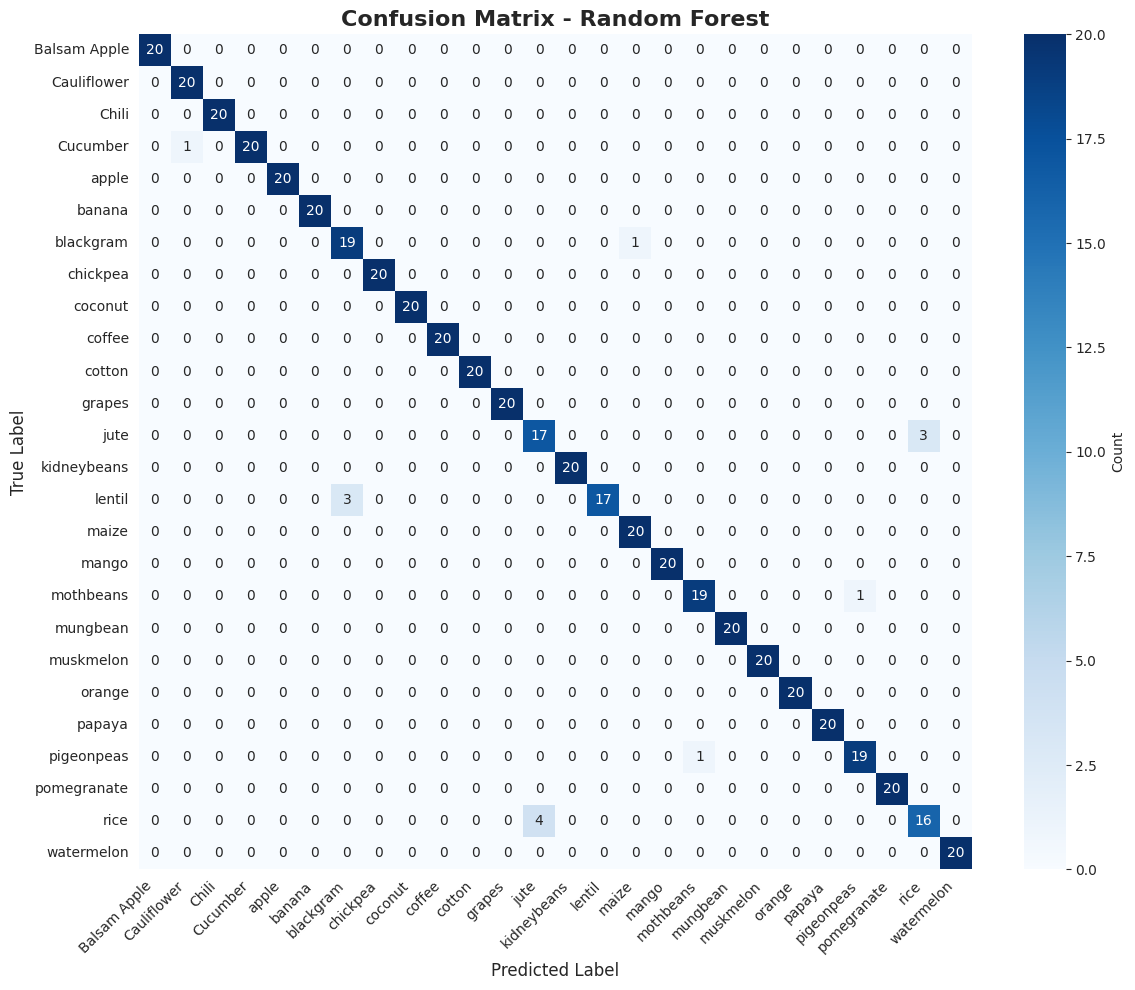

In [24]:
# Confusion Matrix for Best Model
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test_encoded, y_pred_best)

# Get unique labels (original string names)
labels = sorted(y.unique())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Classification Report for Best Model
print(f"Classification Report - {best_model_name}")
print("="*80)
print(classification_report(y_test, y_pred_best))
print("="*80)

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.95      1.00      0.98        20
           2       1.00      1.00      1.00        20
           3       1.00      0.95      0.98        21
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.86      0.95      0.90        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       0.81      0.85      0.83        20
          13       1.00      1.00      1.00        20
          14       1.00      0.85      0.92        20
          15       0.95      1.00      0.98        20
          16       1.00      1.00      1.00

In [27]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nFeature Importance:")
    print(feature_importance)

    # Visualize feature importance
    fig = px.bar(feature_importance, x='Importance', y='Feature',
                 orientation='h',
                 title=f'Feature Importance - {best_model_name}',
                 color='Importance',
                 color_continuous_scale='viridis')
    fig.update_layout(height=400, yaxis={'categoryorder':'total ascending'})
    fig.show()
else:
    print(f"\n{best_model_name} does not provide feature importance.")


Feature Importance:
                Feature  Importance
4              humidity    0.214100
2                     K    0.181243
1                     P    0.153124
0                     N    0.124685
3           temperature    0.118603
5                    ph    0.082600
6                    EC    0.062183
8      weather_humidity    0.013352
10         air_pressure    0.012989
11             rainfall    0.012972
9       light_intensity    0.012260
7   weather_temperature    0.011888


In [28]:
# SHAP Force Plot - Multiple Predictions Visualization
print("\nSHAP Force Plot: Visualize how features contribute to predictions")
print("="*80)

# Select a few samples to visualize
n_samples = min(20, len(X_test_scaled))
print(f"Visualizing {n_samples} predictions...")

if isinstance(shap_values, list):
    # For multi-class, pick the most common predicted class
    predictions = best_model.predict(X_test_scaled[:n_samples])
    most_common_class = pd.Series(predictions).mode()[0]
    class_idx = list(sorted(y.unique())).index(most_common_class)

    shap_vals_plot = shap_values[class_idx][:n_samples]
    expected_val = explainer.expected_value[class_idx]
    print(f"Showing force plot for class: {most_common_class}")
else:
    shap_vals_plot = shap_values[:n_samples]
    expected_val = explainer.expected_value

# Create force plot
shap.force_plot(
    expected_val,
    shap_vals_plot,
    X_test_scaled[:n_samples],
    feature_names=features,
    matplotlib=True,
    show=False
)

plt.title(f'SHAP Force Plot - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("- Each row represents one prediction")
print("- Red: Features pushing prediction higher")
print("- Blue: Features pushing prediction lower")
print("- Width: Magnitude of feature's impact")


SHAP Force Plot: Visualize how features contribute to predictions
Visualizing 20 predictions...


NameError: name 'shap_values' is not defined

## 7.5. SHAP Analysis - Model Interpretability (Initialization)

In [30]:
# Initialize SHAP explainer for the best model
print(f"Creating SHAP explainer for {best_model_name}...")
print("This may take a few moments...\n")

# Select a background dataset (sample for faster computation)
# Using X_train_scaled, the data the model was trained on
background_data = shap.sample(X_train_scaled, 100)

# Create appropriate explainer based on model type
if best_model_name in ['Random Forest', 'Decision Tree', 'XGBoost', 'Gradient Boosting', 'AdaBoost']:
    # Tree-based explainer (faster and more accurate for tree models)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
    print("\u2713 TreeExplainer created successfully!")
else:
    # Kernel explainer (works for any model)
    # For KernelExplainer with multi-class models, the predict function needs to return probabilities
    # or be adapted for multi-output if the model's predict returns class labels directly.
    # Since best_model.predict returns encoded labels, and we need probabilities for SHAP,
    # we will use predict_proba for non-tree models if available.
    if hasattr(best_model, 'predict_proba'):
        explainer = shap.KernelExplainer(best_model.predict_proba, background_data)
        # For multi-output models, shap_values will be a list of arrays
        shap_values = explainer.shap_values(X_test_scaled[:100])  # Limit for faster computation
    else:
        # Fallback if predict_proba is not available, though less ideal for multi-class
        explainer = shap.KernelExplainer(best_model.predict, background_data)
        shap_values = explainer.shap_values(X_test_scaled[:100])
    print("\u2713 KernelExplainer created successfully!")

print(f"SHAP values shape: {np.array(shap_values).shape}")

Creating SHAP explainer for Random Forest...
This may take a few moments...

✓ TreeExplainer created successfully!
SHAP values shape: (521, 12, 26)



SHAP Dependence Plots: How features interact with predictions
Showing dependence plots for all 12 features


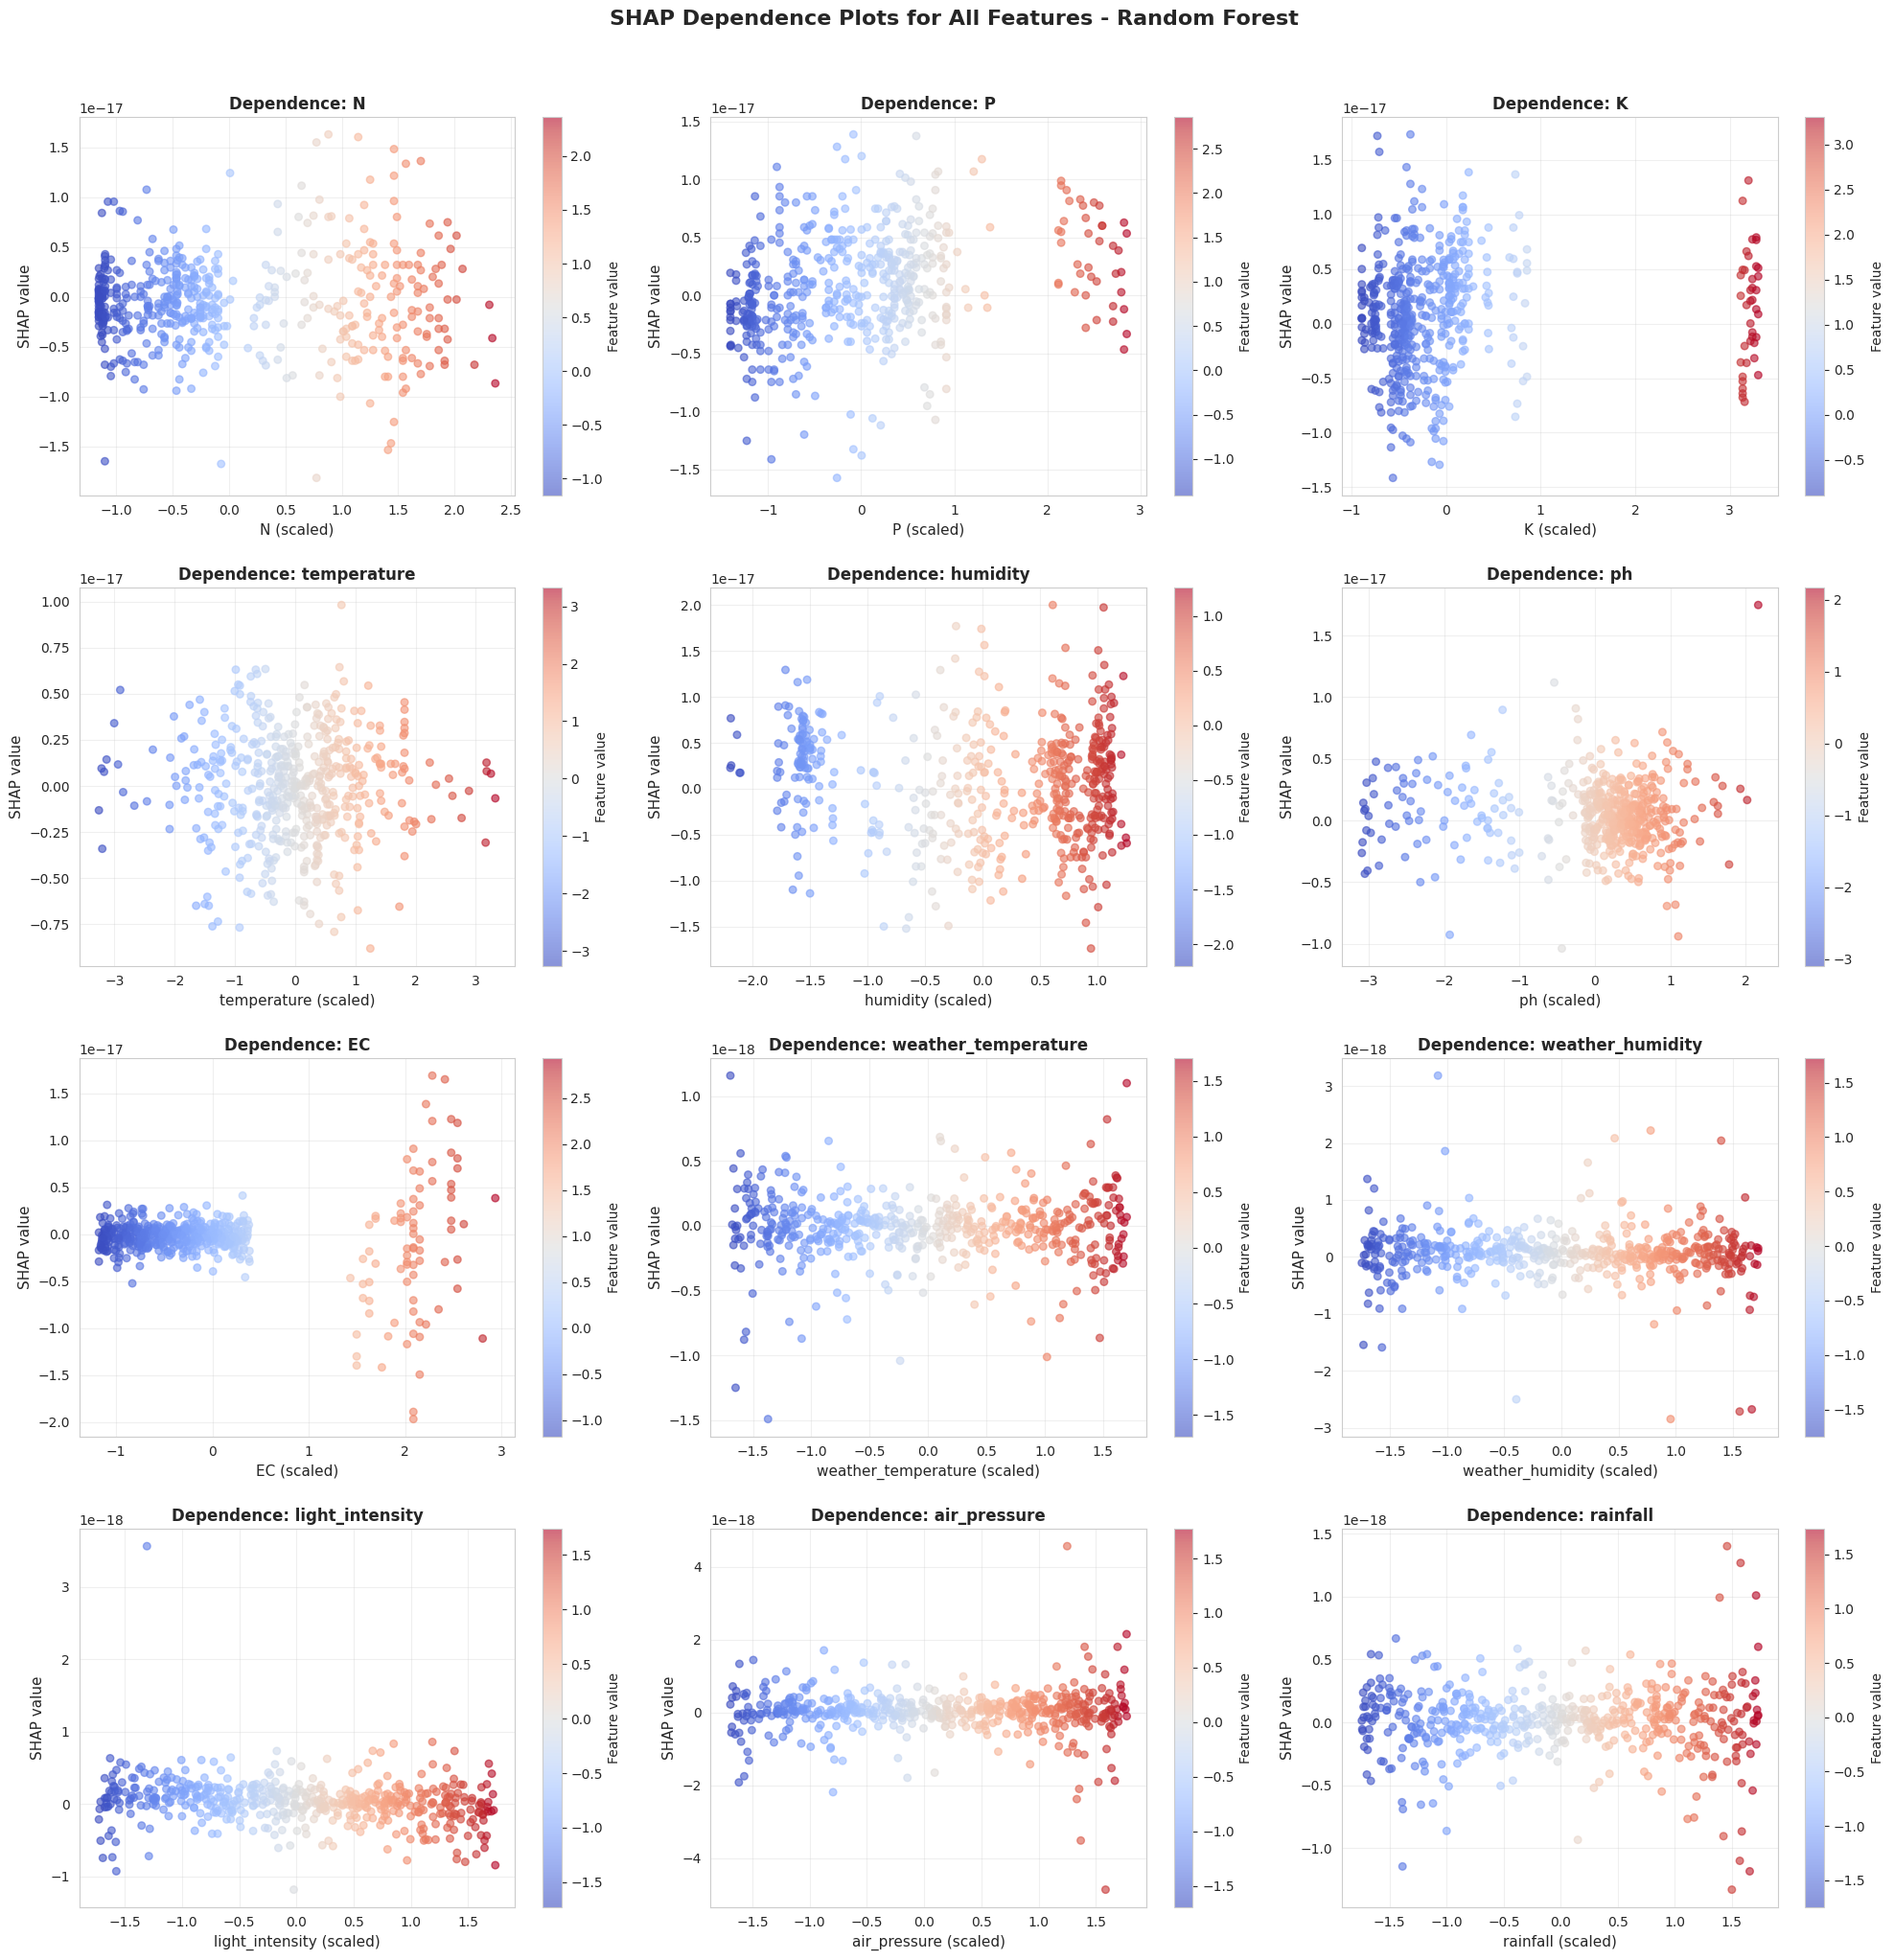


📊 Interpretation:
- X-axis: Feature value
- Y-axis: SHAP value (impact on prediction)
- Color: Feature value intensity
- Shows how feature values relate to their impact on predictions


In [34]:
# SHAP Dependence Plots - Feature Interactions
print("\nSHAP Dependence Plots: How features interact with predictions")
print("="*80)

# Get most important features for dependence plots
if isinstance(shap_values, list):
    # If shap_values is a list of arrays (e.g., from KernelExplainer for multi-output)
    # Aggregate across classes, then across samples
    stacked_shap_values = np.stack(shap_values, axis=-1) # (num_samples, num_features, num_classes)
    shap_abs_mean = np.abs(stacked_shap_values).mean(axis=(0, 2))
else:
    # If shap_values is a single ndarray (e.g., from TreeExplainer for multi-output)
    # Aggregate across samples (axis 0) and classes (axis 2)
    shap_abs_mean = np.abs(shap_values).mean(axis=(0, 2))

# Plot all features instead of just top 3
all_features_idx = np.arange(len(features))
all_features_names = features

print(f"Showing dependence plots for all {len(all_features_names)} features")

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

for idx, (feat_idx, feat_name) in enumerate(zip(all_features_idx, all_features_names)):
    ax = axes[idx]

    # Select appropriate shap values
    if isinstance(shap_values, list):
        # Average across classes for dependence plot
        # stacked_shap_values is (num_samples, num_features, num_classes)
        shap_vals_feature = stacked_shap_values[:, feat_idx, :].mean(axis=1)
    else: # shap_values is (num_samples, num_features, num_classes)
        shap_vals_feature = shap_values[:, feat_idx, :].mean(axis=1) # Average across classes

    # Create scatter plot
    scatter = ax.scatter(
        X_test_scaled[:, feat_idx],
        shap_vals_feature,
        c=X_test_scaled[:, feat_idx],
        cmap='coolwarm',
        alpha=0.6,
        s=30
    )

    ax.set_xlabel(f'{feat_name} (scaled)', fontsize=11)
    ax.set_ylabel('SHAP value', fontsize=11)
    ax.set_title(f'Dependence: {feat_name}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Feature value')

plt.suptitle(f'SHAP Dependence Plots for All Features - {best_model_name}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("- X-axis: Feature value")
print("- Y-axis: SHAP value (impact on prediction)")
print("- Color: Feature value intensity")
print("- Shows how feature values relate to their impact on predictions")


SHAP Waterfall Plot: Explains a single prediction
Explaining prediction for test sample #0
Actual crop: jute
Predicted crop: jute
Correct: ✓

Feature values:
  N: 89.00
  P: 58.00
  K: 35.00
  temperature: 23.99
  humidity: 82.09
  ph: 6.10
  EC: 1.35
  weather_temperature: 20.08
  weather_humidity: 84.86
  light_intensity: 498.86
  air_pressure: 996.21
  rainfall: 28.01


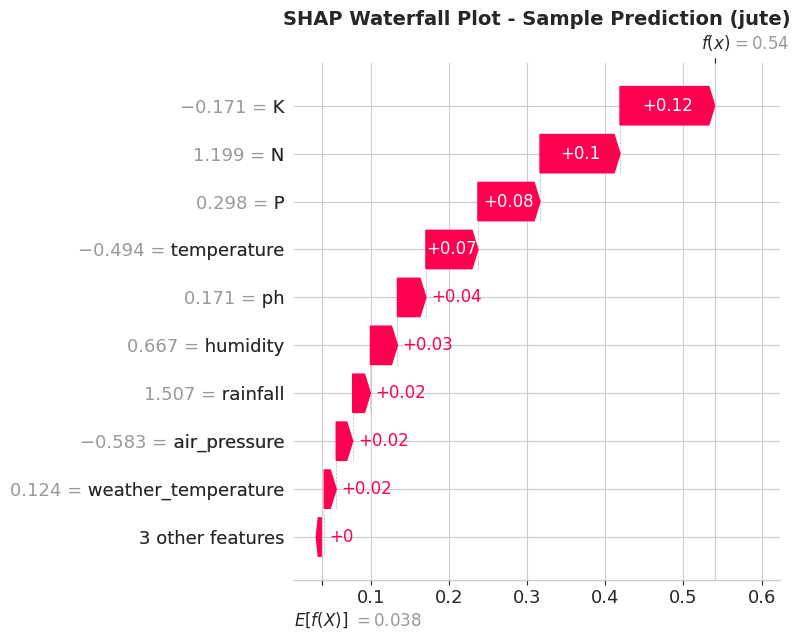


📊 Interpretation:
- Shows how each feature pushes the prediction from base value
- Red arrows push prediction higher
- Blue arrows push prediction lower
- Final value determines the predicted class


In [36]:
# SHAP Waterfall Plot - Individual Prediction Explanation
print("\nSHAP Waterfall Plot: Explains a single prediction")
print("="*80)

# Choose a sample prediction to explain
sample_idx = 0
print(f"Explaining prediction for test sample #{sample_idx}")

# Get the actual prediction
sample_prediction = best_model.predict(X_test_scaled[sample_idx:sample_idx+1])[0]
sample_actual_encoded = y_test_encoded[sample_idx] # Get encoded actual for comparison
sample_actual_str = label_encoder.inverse_transform([sample_actual_encoded])[0] # Get original string actual
sample_prediction_str = label_encoder.inverse_transform([sample_prediction])[0] # Get original string prediction

print(f"Actual crop: {sample_actual_str}")
print(f"Predicted crop: {sample_prediction_str}") # Print string label
print(f"Correct: {'✓' if sample_prediction == sample_actual_encoded else '✗'}") # Compare encoded values
print(f"\nFeature values:")
for feat, val in zip(features, X_test.iloc[sample_idx]):
    print(f"  {feat}: {val:.2f}")

# Create waterfall plot
# The shap_values from TreeExplainer for multi-class is (num_samples, num_features, num_classes)
# We need to select the explanation for a specific sample AND a specific class
predicted_class_idx_for_shap = sample_prediction # sample_prediction is already the encoded class index

shap_values_sample = shap_values[sample_idx, :, predicted_class_idx_for_shap]
expected_value_for_plot = explainer.expected_value[predicted_class_idx_for_shap]

# Create explanation object for waterfall plot
explanation = shap.Explanation(
    values=shap_values_sample,
    base_values=expected_value_for_plot,
    data=X_test_scaled[sample_idx],
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.title(f'SHAP Waterfall Plot - Sample Prediction ({sample_prediction_str})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("- Shows how each feature pushes the prediction from base value")
print("- Red arrows push prediction higher")
print("- Blue arrows push prediction lower")
print("- Final value determines the predicted class")


SHAP Bar Plot: Average impact of each feature


<Figure size 1000x600 with 0 Axes>

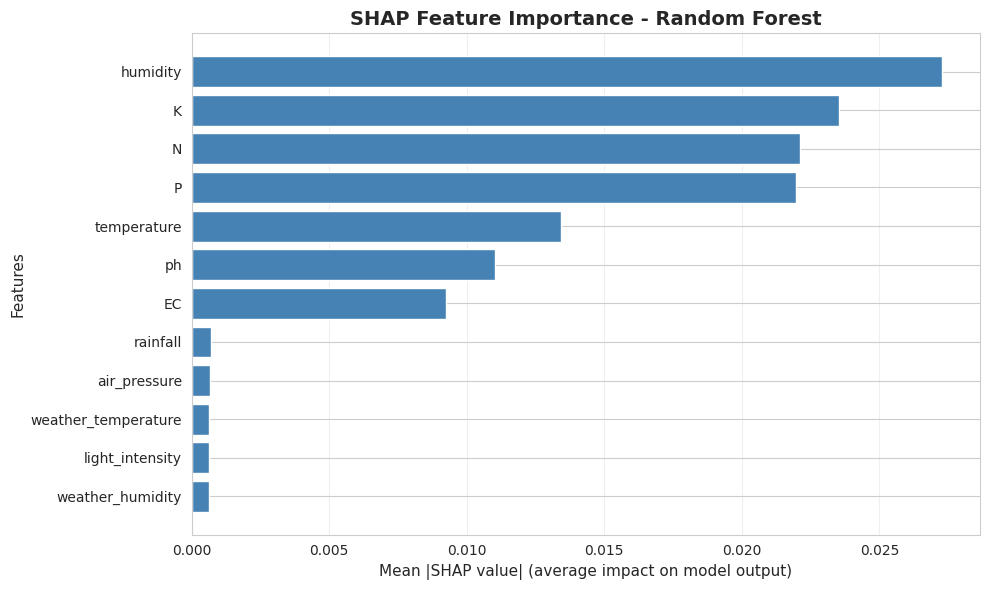


Feature Importance Ranking:
  humidity: 0.0273
  K: 0.0235
  N: 0.0221
  P: 0.0220
  temperature: 0.0134
  ph: 0.0110
  EC: 0.0092
  rainfall: 0.0007
  air_pressure: 0.0007
  weather_temperature: 0.0006
  light_intensity: 0.0006
  weather_humidity: 0.0006


In [38]:
# SHAP Bar Plot - Mean Absolute SHAP Values
print("\nSHAP Bar Plot: Average impact of each feature")
print("="*80)

plt.figure(figsize=(10, 6))

if isinstance(shap_values, list):
    # For multi-class, aggregate across all classes
    shap_abs_mean = np.abs(np.array(shap_values)).mean(axis=0).mean(axis=0)
else:
    # If shap_values is a single ndarray (e.g., from TreeExplainer for multi-output)
    # Aggregate across samples (axis 0) and classes (axis 2)
    shap_abs_mean = np.abs(shap_values).mean(axis=(0, 2))

# Create dataframe for plotting
shap_importance = pd.DataFrame({
    'Feature': features,
    'Mean |SHAP value|': shap_abs_mean
}).sort_values('Mean |SHAP value|', ascending=True)

# Plot
plt.barh(shap_importance['Feature'], shap_importance['Mean |SHAP value|'], color='steelblue')
plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for idx, row in shap_importance.iloc[::-1].iterrows():
    print(f"  {row['Feature']}: {row['Mean |SHAP value|']:.4f}")

SHAP Summary Plot: Shows how each feature impacts the model across all predictions


<Figure size 1200x800 with 0 Axes>

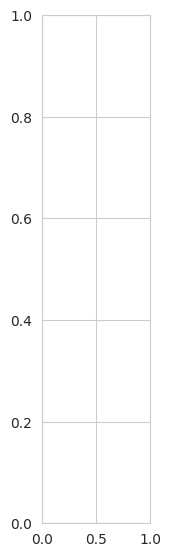

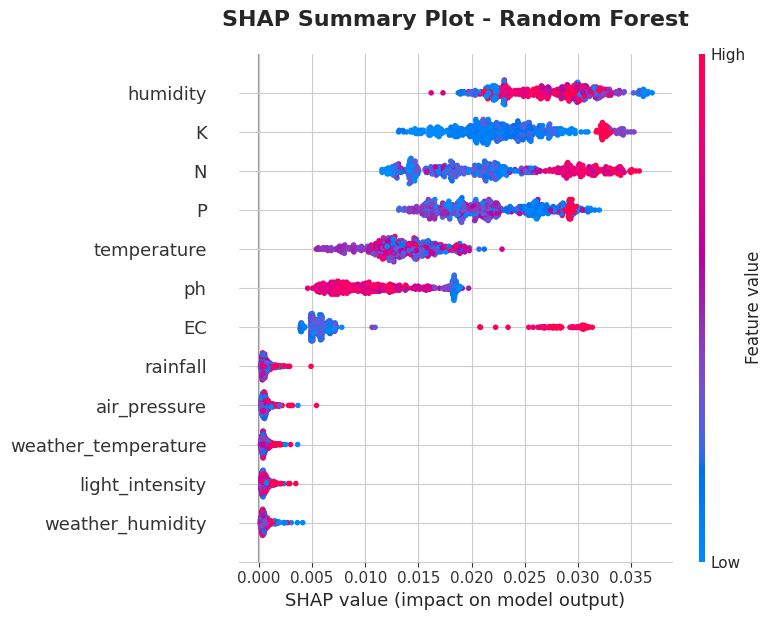


📊 Interpretation:
- Each dot represents a sample
- Position on x-axis: SHAP value (impact on prediction)
- Color: Feature value (red=high, blue=low)
- Features are ordered by importance (top to bottom)


In [40]:
# SHAP Summary Plot - Global Feature Importance
print("SHAP Summary Plot: Shows how each feature impacts the model across all predictions")
print("="*80)

plt.figure(figsize=(12, 8))

# For multi-class classification, we need to handle shap_values differently
if isinstance(shap_values, list):
    # If shap_values is a list of arrays (e.g., from KernelExplainer for multi-output)
    # Stack them to create a (num_samples, num_features, num_classes) array
    # Then take the mean absolute value across classes to get (num_samples, num_features)
    shap_values_to_plot = np.abs(np.stack(shap_values, axis=-1)).mean(axis=-1)
else:
    # If shap_values is a single ndarray (e.g., from TreeExplainer for multi-output)
    # It's already (num_samples, num_features, num_classes)
    # Take the mean absolute value across classes to get (num_samples, num_features)
    shap_values_to_plot = np.abs(shap_values).mean(axis=2)

shap.summary_plot(shap_values_to_plot, X_test_scaled, feature_names=features, show=False)

plt.title(f'SHAP Summary Plot - {best_model_name}', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("- Each dot represents a sample")
print("- Position on x-axis: SHAP value (impact on prediction)")
print("- Color: Feature value (red=high, blue=low)")
print("- Features are ordered by importance (top to bottom)")

In [41]:
# Initialize SHAP explainer for the best model
print(f"Creating SHAP explainer for {best_model_name}...")
print("This may take a few moments...\n")

# Select a background dataset (sample for faster computation)
background_data = shap.sample(X_train_scaled, 100)

# Create appropriate explainer based on model type
if best_model_name in ['Random Forest', 'Decision Tree', 'XGBoost', 'Gradient Boosting', 'AdaBoost']:
    # Tree-based explainer (faster and more accurate for tree models)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
    print("✓ TreeExplainer created successfully!")
else:
    # Kernel explainer (works for any model)
    explainer = shap.KernelExplainer(best_model.predict, background_data)
    shap_values = explainer.shap_values(X_test_scaled[:100])  # Limit for faster computation
    print("✓ KernelExplainer created successfully!")

print(f"SHAP values shape: {np.array(shap_values).shape}")

Creating SHAP explainer for Random Forest...
This may take a few moments...

✓ TreeExplainer created successfully!
SHAP values shape: (521, 12, 26)


## 7.5. SHAP Analysis - Model Interpretability

SHAP (SHapley Additive exPlanations) helps explain how each feature contributes to the model's predictions.

## 8. Statistical Model Comparison

Using different statistical tests to validate model selection

In [43]:
# Stratified K-Fold Cross-Validation for top models
# Get top 5 models by accuracy
top_5_models = results_df.nlargest(5, 'Accuracy').index.tolist()

print("Detailed Cross-Validation Analysis for Top 5 Models:")
print("="*80)

skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results_detailed = {}

for model_name in top_5_models:
    model = trained_models[model_name]
    cv_scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=skfold, scoring='accuracy')
    cv_results_detailed[model_name] = cv_scores

    print(f"\n{model_name}:")
    print(f"  Mean Accuracy: {cv_scores.mean():.4f}")
    print(f"  Std Deviation: {cv_scores.std():.4f}")
    print(f"  Min Accuracy: {cv_scores.min():.4f}")
    print(f"  Max Accuracy: {cv_scores.max():.4f}")
    print(f"  All Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")

print("\n" + "="*80)

Detailed Cross-Validation Analysis for Top 5 Models:

Random Forest:
  Mean Accuracy: 0.9625
  Std Deviation: 0.0077
  Min Accuracy: 0.9519
  Max Accuracy: 0.9760
  All Fold Scores: ['0.9615', '0.9567', '0.9663', '0.9519', '0.9663', '0.9519', '0.9663', '0.9567', '0.9760', '0.9712']

XGBoost:
  Mean Accuracy: 0.9625
  Std Deviation: 0.0132
  Min Accuracy: 0.9423
  Max Accuracy: 0.9904
  All Fold Scores: ['0.9712', '0.9519', '0.9615', '0.9567', '0.9663', '0.9471', '0.9712', '0.9423', '0.9904', '0.9663']

Decision Tree:
  Mean Accuracy: 0.9505
  Std Deviation: 0.0105
  Min Accuracy: 0.9327
  Max Accuracy: 0.9712
  All Fold Scores: ['0.9519', '0.9327', '0.9471', '0.9375', '0.9471', '0.9471', '0.9567', '0.9615', '0.9712', '0.9519']

Gradient Boosting:
  Mean Accuracy: 0.9620
  Std Deviation: 0.0111
  Min Accuracy: 0.9471
  Max Accuracy: 0.9808
  All Fold Scores: ['0.9615', '0.9615', '0.9567', '0.9471', '0.9663', '0.9471', '0.9760', '0.9519', '0.9808', '0.9712']

Naive Bayes:
  Mean Accuracy

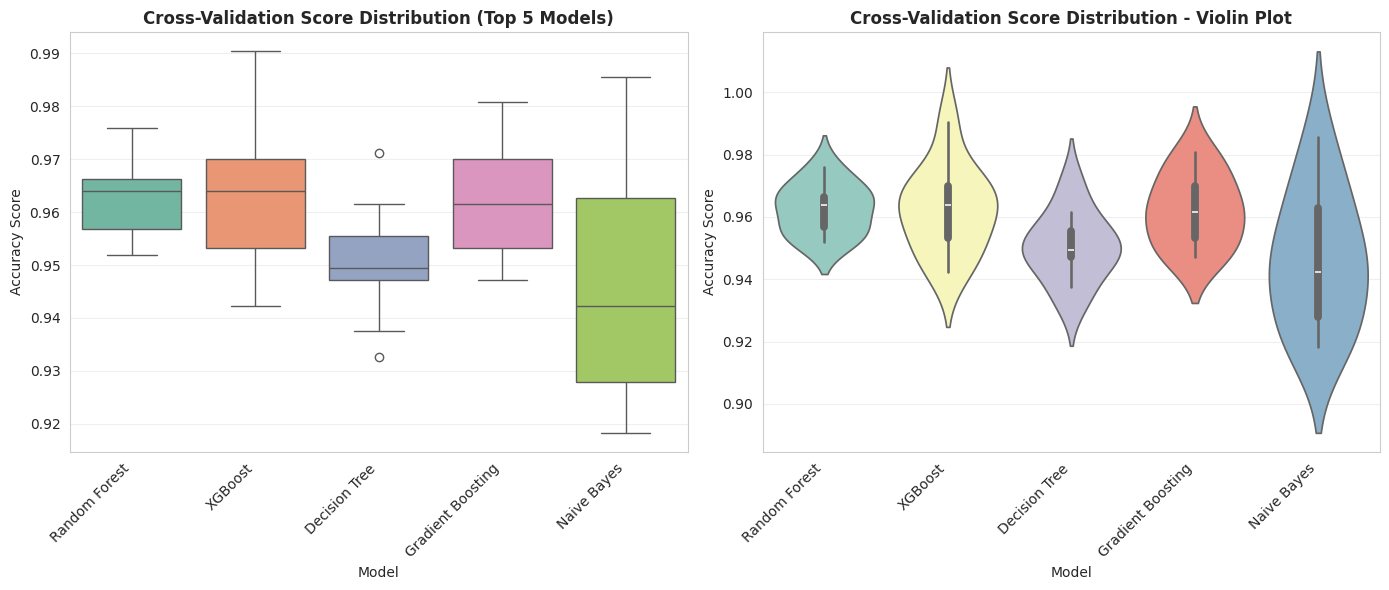

In [44]:
# Visualize cross-validation scores
plt.figure(figsize=(14, 6))

# Box plot
plt.subplot(1, 2, 1)
cv_df = pd.DataFrame(cv_results_detailed)
sns.boxplot(data=cv_df, palette='Set2')
plt.title('Cross-Validation Score Distribution (Top 5 Models)', fontweight='bold')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(data=cv_df, palette='Set3')
plt.title('Cross-Validation Score Distribution - Violin Plot', fontweight='bold')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

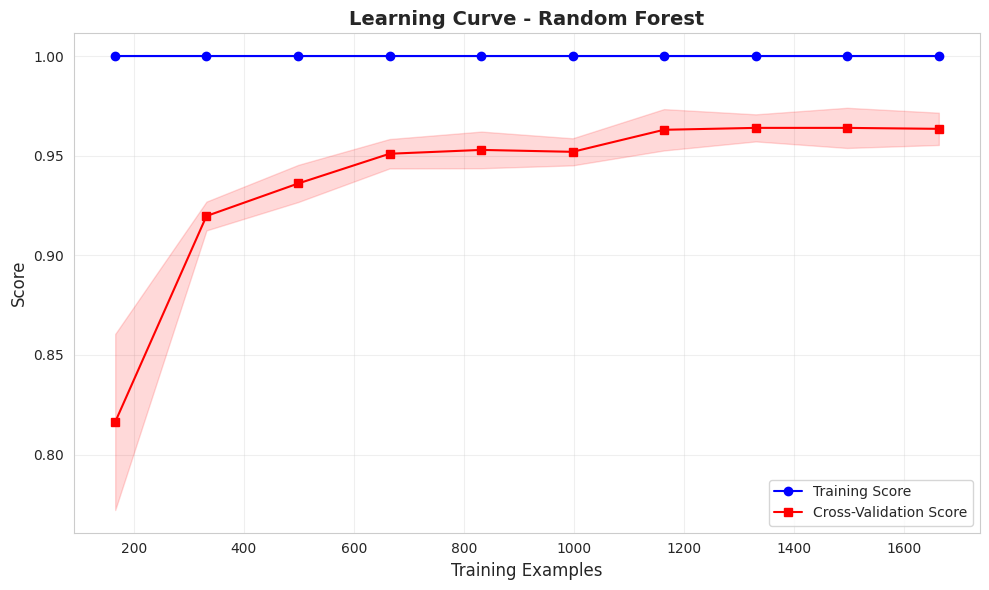

In [45]:
# Learning Curve for Best Model
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_scaled, y_train,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', marker='s', color='red')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='red')

plt.title(f'Learning Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Using the Best Model for Predictions

In [46]:
# Create a prediction function
def predict_crop(n, p, k, temperature, humidity, ph, ec, weather_temp, weather_humidity,
                 light_intensity, air_pressure, rainfall):
    """
    Predict the recommended crop based on soil and environmental parameters

    Parameters:
    - n: Nitrogen content
    - p: Phosphorus content
    - k: Potassium content
    - temperature: Temperature in degrees Celsius
    - humidity: Humidity percentage
    - ph: pH value of soil
    - ec: Electrical Conductivity
    - weather_temp: Weather temperature
    - weather_humidity: Weather humidity
    - light_intensity: Light intensity
    - air_pressure: Air pressure in hPa
    - rainfall: Rainfall in mm

    Returns:
    - Predicted crop name
    - Prediction probabilities for all crops
    """
    # Create input array with all 12 features
    input_data = np.array([[n, p, k, temperature, humidity, ph, ec, weather_temp,
                           weather_humidity, light_intensity, air_pressure, rainfall]])

    # Scale the input
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = best_model.predict(input_scaled)[0]

    # Get prediction probabilities
    if hasattr(best_model, 'predict_proba'):
        probabilities = best_model.predict_proba(input_scaled)[0]
        prob_dict = dict(zip(sorted(y.unique()), probabilities))
        prob_dict = {k: v for k, v in sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)}
    else:
        prob_dict = None

    return prediction, prob_dict

print("Prediction function created successfully!")
print(f"Best Model for predictions: {best_model_name}")
print(f"Required features (12): {features}")

Prediction function created successfully!
Best Model for predictions: Random Forest
Required features (12): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'EC', 'weather_temperature', 'weather_humidity', 'light_intensity', 'air_pressure', 'rainfall']


In [49]:
# Test the prediction function with sample data
print("Testing Prediction Function with Sample Data:")
print("="*80)

# Test with a few samples from the test set
test_samples = X_test.iloc[:5]

for i, (idx, row) in enumerate(test_samples.iterrows(), 1):
    print(f"\nSample {i}:")
    print(f"  N: {row['N']:.2f}, P: {row['P']:.2f}, K: {row['K']:.2f}")
    print(f"  Temperature: {row['temperature']:.2f}°C, Humidity: {row['humidity']:.2f}%")
    print(f"  pH: {row['ph']:.2f}, EC: {row['EC']:.2f}")
    print(f"  Weather: {row['weather_temperature']:.2f}°C, {row['weather_humidity']:.2f}%")
    print(f"  Light: {row['light_intensity']:.2f}, Pressure: {row['air_pressure']:.2f} hPa")
    print(f"  Rainfall: {row['rainfall']:.2f} mm")

    # Create input from all features
    input_data = np.array([[row[f] for f in features]])
    input_scaled = scaler.transform(input_data)

    # Get encoded prediction
    encoded_prediction = best_model.predict(input_scaled)[0]
    # Decode prediction to string
    predicted_crop_str = label_encoder.inverse_transform([encoded_prediction])[0]

    # Get probabilities
    if hasattr(best_model, 'predict_proba'):
        probabilities = best_model.predict_proba(input_scaled)[0]
        prob_dict = dict(zip(sorted(y.unique()), probabilities))
        probabilities = {k: v for k, v in sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)}
    else:
        probabilities = None

    actual = y_test.iloc[i-1]
    print(f"  Predicted Crop: {predicted_crop_str}") # Print string prediction
    print(f"  Actual Crop: {actual}")
    print(f"  Correct: {'✓' if predicted_crop_str == actual else '✗'}") # Compare string predictions

    if probabilities:

        print(f"  Top 3 Predictions:")
        print("="*80)

        for crop, prob in list(probabilities.items())[:3]:

            print(f"    - {crop}: {prob*100:.2f}%")
        print("-" * 80)

Testing Prediction Function with Sample Data:

Sample 1:
  N: 89.00, P: 58.00, K: 35.00
  Temperature: 23.99°C, Humidity: 82.09%
  pH: 6.10, EC: 1.35
  Weather: 20.08°C, 84.86%
  Light: 498.86, Pressure: 996.21 hPa
  Rainfall: 28.01 mm
  Predicted Crop: jute
  Actual Crop: jute
  Correct: ✓
  Top 3 Predictions:
    - jute: 54.00%
    - rice: 40.00%
    - coffee: 2.00%
--------------------------------------------------------------------------------

Sample 2:
  N: 90.00, P: 92.00, K: 55.00
  Temperature: 27.01°C, Humidity: 80.19%
  pH: 6.13, EC: 2.23
  Weather: 19.83°C, 49.56%
  Light: 506.57, Pressure: 1013.93 hPa
  Rainfall: 18.69 mm
  Predicted Crop: banana
  Actual Crop: banana
  Correct: ✓
  Top 3 Predictions:
    - banana: 90.00%
    - watermelon: 5.00%
    - jute: 3.00%
--------------------------------------------------------------------------------

Sample 3:
  N: 26.00, P: 52.00, K: 23.00
  Temperature: 29.99°C, Humidity: 49.60%
  pH: 4.93, EC: 1.86
  Weather: 16.10°C, 82.12%
 

## 10. Model Persistence (Save Model)

In [50]:
# Save the best model and scaler for future use
import pickle
import joblib

# Save using pickle
with open('best_crop_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Alternative: Save using joblib (recommended for large models)
joblib.dump(best_model, 'best_crop_model_joblib.pkl')
joblib.dump(scaler, 'scaler_joblib.pkl')

# Save model information
model_info = {
    'model_name': best_model_name,
    'accuracy': results_df.loc[best_model_name, 'Accuracy'],
    'f1_score': results_df.loc[best_model_name, 'F1-Score'],
    'cv_score': results_df.loc[best_model_name, 'CV Mean'],
    'features': features,
    'classes': sorted(y.unique())
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("✓ Model saved successfully!")
print(f"  - best_crop_model.pkl (pickle format)")
print(f"  - best_crop_model_joblib.pkl (joblib format)")
print(f"  - scaler.pkl")
print(f"  - scaler_joblib.pkl")
print(f"  - model_info.pkl")
print("\nYou can load the model later using:")
print("  loaded_model = pickle.load(open('best_crop_model.pkl', 'rb'))")
print("  loaded_scaler = pickle.load(open('scaler.pkl', 'rb'))")

✓ Model saved successfully!
  - best_crop_model.pkl (pickle format)
  - best_crop_model_joblib.pkl (joblib format)
  - scaler.pkl
  - scaler_joblib.pkl
  - model_info.pkl

You can load the model later using:
  loaded_model = pickle.load(open('best_crop_model.pkl', 'rb'))
  loaded_scaler = pickle.load(open('scaler.pkl', 'rb'))


## 11. Summary and Conclusions

In [51]:
# Final Summary
print("="*80)
print(" "*25 + "CROP RECOMMENDATION SYSTEM")
print(" "*30 + "FINAL SUMMARY")
print("="*80)

print("\n📊 DATASET INFORMATION:")
print(f"  - Total Samples: {len(df)}")
print(f"  - Number of Features: {len(features)}")
print(f"  - Number of Crop Classes: {y.nunique()}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Testing Samples: {len(X_test)}")

print("\n🔧 PREPROCESSING:")
print("  - Feature Scaling: StandardScaler")
print("  - Train-Test Split: 80-20")
print("  - Stratified Sampling: Yes")

print("\n🤖 MODELS EVALUATED:")
for i, model_name in enumerate(models.keys(), 1):
    print(f"  {i}. {model_name}")

print("\n🏆 BEST MODEL:")
print(f"  Model: {best_model_name}")
print(f"  Test Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f} ({results_df.loc[best_model_name, 'Accuracy']*100:.2f}%)")
print(f"  F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"  Precision: {results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"  Recall: {results_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  Cross-Validation Score: {results_df.loc[best_model_name, 'CV Mean']:.4f} (±{results_df.loc[best_model_name, 'CV Std']:.4f})")

print("\n📈 MODEL COMPARISON:")
print("  Top 3 Models by Accuracy:")
for i, (model_name, row) in enumerate(results_df.nlargest(3, 'Accuracy').iterrows(), 1):
    print(f"    {i}. {model_name}: {row['Accuracy']:.4f}")

print("\n✅ VALIDATION METHODS USED:")
print("  - Train-Test Split Validation")
print("  - 5-Fold Cross-Validation")
print("  - 10-Fold Stratified Cross-Validation")
print("  - Learning Curve Analysis")
print("  - Confusion Matrix")
print("  - Classification Report")

print("\n💾 OUTPUT FILES:")
print("  - best_crop_model.pkl")
print("  - scaler.pkl")
print("  - model_info.pkl")

print("\n📝 RECOMMENDATIONS:")
print(f"  The {best_model_name} is recommended for crop prediction")
print("  based on comprehensive evaluation across multiple metrics")
print("  and validation methods.")

print("\n" + "="*80)
print("Analysis Complete! The model is ready for deployment.")
print("="*80)

                         CROP RECOMMENDATION SYSTEM
                              FINAL SUMMARY

📊 DATASET INFORMATION:
  - Total Samples: 2601
  - Number of Features: 12
  - Number of Crop Classes: 26
  - Training Samples: 2080
  - Testing Samples: 521

🔧 PREPROCESSING:
  - Feature Scaling: StandardScaler
  - Train-Test Split: 80-20
  - Stratified Sampling: Yes

🤖 MODELS EVALUATED:
  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. Gradient Boosting
  5. XGBoost
  6. SVM
  7. KNN
  8. Naive Bayes
  9. AdaBoost

🏆 BEST MODEL:
  Model: Random Forest
  Test Accuracy: 0.9731 (97.31%)
  F1-Score: 0.9731
  Precision: 0.9739
  Recall: 0.9731
  Cross-Validation Score: 0.9635 (±0.0081)

📈 MODEL COMPARISON:
  Top 3 Models by Accuracy:
    1. Random Forest: 0.9731
    2. XGBoost: 0.9616
    3. Decision Tree: 0.9520

✅ VALIDATION METHODS USED:
  - Train-Test Split Validation
  - 5-Fold Cross-Validation
  - 10-Fold Stratified Cross-Validation
  - Learning Curve Analysis
  - Confus

In [54]:
# Interactive prediction function for easy testing
def interactive_crop_recommendation():
    """
    Interactive function to get crop recommendations
    Perfect for Google Colab and Jupyter notebooks
    """
    print("="*80)
    print(" "*20 + "🌾 CROP RECOMMENDATION SYSTEM 🌾")
    print("="*80)

    try:
        # Get user input
        print("\nEnter soil and environmental conditions:")
        n = float(input("  Nitrogen (N): "))
        p = float(input("  Phosphorus (P): "))
        k = float(input("  Potassium (K): "))
        temp = float(input("  Temperature (°C): "))
        humidity = float(input("  Humidity (%): "))
        ph = float(input("  pH: "))
        ec = float(input("  EC: "))
        w_temp = float(input("  Weather Temperature (°C): "))
        w_humidity = float(input("  Weather Humidity (%): "))
        light = float(input("  Light Intensity: "))
        pressure = float(input("  Air Pressure (hPa): "))
        rainfall = float(input("  Rainfall (mm): "))

        # Use the full feature array for prediction
        input_data = np.array([[n, p, k, temp, humidity, ph, ec, w_temp,
                               w_humidity, light, pressure, rainfall]])
        input_scaled = scaler.transform(input_data)

        encoded_prediction = best_model.predict(input_scaled)[0]
        predicted_crop_str = label_encoder.inverse_transform([encoded_prediction])[0]

        if hasattr(best_model, 'predict_proba'):
            probabilities = best_model.predict_proba(input_scaled)[0]
            prob_dict = dict(zip(sorted(y.unique()), probabilities))
            probs_sorted = {k: v for k, v in sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)}
        else:
            probs_sorted = None

        # Display results
        print("\n" + "="*80)
        print(" "*25 + "📊 RECOMMENDATION RESULTS")
        print("="*80)

        print(f"\n🌾 RECOMMENDED CROP: {predicted_crop_str.upper()}")

        if probs_sorted:
            print(f"\n📈 Confidence Scores:")
            print("-" * 60)
            for i, (crop, prob) in enumerate(list(probs_sorted.items())[:5], 1):
                bar_length = int(prob * 40)
                bar = "█" * bar_length + "░" * (40 - bar_length)
                print(f"  {i}. {crop:20s} {bar} {prob*100:5.2f}%")
        print("\n" + "="*80)

    except ValueError:
        print("\nError: Please enter valid numerical values for all parameters.")
    except Exception as e:
        print(f"\nAn unexpected error occurred: {e}")

def quick_predict(n, p, k, temp, humidity, ph, ec, w_temp, w_humidity, light, pressure, rainfall):
    """
    Quickly predict the recommended crop based on given parameters.
    """
    input_data = np.array([[n, p, k, temp, humidity, ph, ec, w_temp,
                           w_humidity, light, pressure, rainfall]])
    input_scaled = scaler.transform(input_data)

    encoded_prediction = best_model.predict(input_scaled)[0]
    predicted_crop_str = label_encoder.inverse_transform([encoded_prediction])[0]

    probs_sorted = None
    if hasattr(best_model, 'predict_proba'):
        probabilities = best_model.predict_proba(input_scaled)[0]
        prob_dict = dict(zip(sorted(y.unique()), probabilities))
        probs_sorted = {k: v for k, v in sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)}

    print("✓ Recommendation complete!")
    print("="*80)
    print(f"🌾 Recommended Crop: {predicted_crop_str}")
    if probs_sorted:
        print(f"📊 Top 3: {', '.join([f'{k}({v*100:.1f}%)' for k, v in list(probs_sorted.items())[:3]])}")

    return predicted_crop_str, probs_sorted

print("✓ Interactive functions created!")

print("\nUsage:")
print("  interactive_crop_recommendation()  # For interactive input")
print("  quick_predict(90, 42, 43, 20, 65, 6.5, 2.5, 20, 65, 500, 1010, 15)  # For quick predictions")
print("  Parameters: N, P, K, temp, humidity, pH, EC, weather_temp, weather_humidity, light, pressure, rainfall")

✓ Interactive functions created!

Usage:
  interactive_crop_recommendation()  # For interactive input
  quick_predict(90, 42, 43, 20, 65, 6.5, 2.5, 20, 65, 500, 1010, 15)  # For quick predictions
  Parameters: N, P, K, temp, humidity, pH, EC, weather_temp, weather_humidity, light, pressure, rainfall


## 🎯 Quick Start Guide

### For Google Colab Users:

1. **Upload your data**: Run the Colab Setup section (cell 2-3) to upload `useable_dataset - useable_dataset.csv`

2. **Run all cells**: Go to Runtime → Run all

3. **Get predictions**: Use either:
   ```python
   # Interactive mode (will prompt for all 12 features)
   interactive_crop_recommendation()
   
   # Quick prediction (all 12 parameters required)
   quick_predict(90, 42, 43, 20, 65, 6.5, 2.5, 20, 65, 500, 1010, 15)
   # Parameters: N, P, K, temp, humidity, pH, EC, weather_temp, weather_humidity, light, pressure, rainfall
   ```

### Dataset Information:

📊 **12 Input Features**:
- **Soil Nutrients**: N, P, K (Nitrogen, Phosphorus, Potassium)
- **Soil Properties**: pH, EC (Electrical Conductivity)
- **Climate**: temperature, humidity, weather_temperature, weather_humidity, rainfall
- **Environment**: light_intensity, air_pressure

🎯 **Target**: crop (crop type recommendation)

### Key Features of This Notebook:

✅ **12 Features** for comprehensive crop recommendation
✅ **9 Machine Learning Models** compared and evaluated
✅ **Multiple validation methods**: Train-test split, 5-fold CV, 10-fold stratified CV
✅ **SHAP Analysis** for model interpretability and explainability
✅ **Complete Pipeline Class** for easy deployment
✅ **Interactive Predictions** for testing
✅ **Model Persistence** - save and load trained models
✅ **Production-Ready** code with best practices

### Output Files Generated:

- `best_crop_model.pkl` / `best_crop_model_joblib.pkl` - Trained model
- `scaler.pkl` / `scaler_joblib.pkl` - Feature scaler
- `model_info.pkl` - Model metadata
- `crop_recommendation_pipeline/` - Complete pipeline folder

### Next Steps:

1. **Deploy to Web App**: Use the pipeline class with Flask/FastAPI
2. **Mobile Integration**: Load the pickle files in your app
3. **API Development**: Create REST API endpoints using the pipeline
4. **Real-time Predictions**: Connect to IoT sensors for live recommendations
5. **Integration**: Use with weather APIs and soil sensors for automated predictions

## 13. Interactive Prediction Widget (Colab-Friendly)

In [ ]:
# Example: Load a saved pipeline and use it for predictions
print("="*80)
print("LOADING SAVED PIPELINE")
print("="*80)

# Create a new pipeline instance
loaded_pipeline = CropRecommendationPipeline()

# Load the saved pipeline
loaded_pipeline.load_pipeline(folder_path='crop_recommendation_pipeline')

# Make a prediction with the loaded pipeline (all 12 features required)
print("\nMaking prediction with loaded pipeline...")
prediction, probs = loaded_pipeline.predict(90, 42, 43, 22.0, 75.0, 6.5, 2.5, 21.0, 70.0, 600.0, 1012.0, 18.0)

print(f"\n🌾 Recommended Crop: {prediction}")
if probs:
    print(f"📊 Confidence Scores:")
    for crop, prob in list(probs.items())[:5]:
        print(f"   {crop}: {prob*100:.2f}%")

print("\n" + "="*80)
print("✓ Loaded pipeline works perfectly!")
print("="*80)

### Loading and Using a Saved Pipeline

In [ ]:
# Test the pipeline with predictions
print("\n" + "="*80)
print("TESTING PIPELINE PREDICTIONS")
print("="*80)

# Test with some examples (using all 12 features)
test_cases = [
    {"N": 90, "P": 42, "K": 43, "temp": 20.5, "humidity": 80.0, "ph": 6.5, "EC": 2.5,
     "w_temp": 20.0, "w_humidity": 65.0, "light": 500.0, "pressure": 1010.0, "rainfall": 15.0},
    {"N": 85, "P": 58, "K": 41, "temp": 25.0, "humidity": 82.0, "ph": 7.0, "EC": 2.2,
     "w_temp": 24.0, "w_humidity": 70.0, "light": 700.0, "pressure": 1015.0, "rainfall": 25.0},
    {"N": 60, "P": 55, "K": 44, "temp": 23.0, "humidity": 83.0, "ph": 7.8, "EC": 3.1,
     "w_temp": 22.0, "w_humidity": 75.0, "light": 600.0, "pressure": 1020.0, "rainfall": 20.0},
]

for i, test_case in enumerate(test_cases, 1):
    print(f"\nTest Case {i}:")
    print(f"  N={test_case['N']}, P={test_case['P']}, K={test_case['K']}")
    print(f"  Temperature: {test_case['temp']}°C, Humidity: {test_case['humidity']}%")
    print(f"  pH: {test_case['ph']}, EC: {test_case['EC']}")
    print(f"  Weather: {test_case['w_temp']}°C, {test_case['w_humidity']}%")
    print(f"  Light: {test_case['light']}, Pressure: {test_case['pressure']} hPa")
    print(f"  Rainfall: {test_case['rainfall']} mm")

    # Make prediction with all features
    prediction, probabilities = pipeline.predict(
        test_case['N'], test_case['P'], test_case['K'],
        test_case['temp'], test_case['humidity'], test_case['ph'], test_case['EC'],
        test_case['w_temp'], test_case['w_humidity'],
        test_case['light'], test_case['pressure'], test_case['rainfall']
    )

    print(f"\n  🌾 Recommended Crop: {prediction}")

    if probabilities:
        print(f"  📊 Top 3 Recommendations:")
        for crop, prob in list(probabilities.items())[:3]:
            print(f"     {crop}: {prob*100:.2f}%")

    print("-" * 80)print("\n" + "="*80)


In [ ]:
# Example: Using the complete pipeline
print("="*80)
print("COMPLETE PIPELINE DEMONSTRATION")
print("="*80)

# Initialize pipeline
pipeline = CropRecommendationPipeline()

# Load data
X, y = pipeline.load_data('useable_dataset - useable_dataset.csv', target_column='crop')

# Preprocess
X_train_scaled, X_test_scaled = pipeline.preprocess_data(X, y)

# Train models
results_df = pipeline.train_models(X_train_scaled, X_test_scaled, pipeline.y_train, pipeline.y_test)

# Save pipeline
pipeline.save_pipeline(folder_path='crop_recommendation_pipeline')

print("\n" + "="*80)
print("Pipeline training complete!")
print("="*80)

### Using the Complete Pipeline

In [ ]:
class CropRecommendationPipeline:
    """
    Complete pipeline for crop recommendation system

    This class encapsulates the entire workflow from data loading to prediction,
    making it easy to train, save, load, and use the model in production.
    """

    def __init__(self):
        self.models = {}
        self.best_model = None
        self.best_model_name = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.target_classes = None
        self.results = {}
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def load_data(self, file_path, target_column='label'):
        """Load and prepare the dataset"""
        print(f"Loading data from {file_path}...")
        self.df = pd.read_csv(file_path)

        # Identify features and target
        self.feature_names = [col for col in self.df.columns if col != target_column]

        X = self.df[self.feature_names]
        y = self.df[target_column]

        self.target_classes = sorted(y.unique())

        print(f"✓ Data loaded: {self.df.shape[0]} samples, {len(self.feature_names)} features")
        print(f"✓ Target classes: {len(self.target_classes)}")

        return X, y

    def preprocess_data(self, X, y, test_size=0.2, random_state=42):
        """Split and scale the data"""
        print("\nPreprocessing data...")

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scale features
        X_train_scaled = self.scaler.fit_transform(self.X_train)
        X_test_scaled = self.scaler.transform(self.X_test)

        print(f"✓ Train set: {len(self.X_train)} samples")
        print(f"✓ Test set: {len(self.X_test)} samples")
        print(f"✓ Features scaled using StandardScaler")

        return X_train_scaled, X_test_scaled

    def train_models(self, X_train_scaled, X_test_scaled, y_train, y_test):
        """Train multiple models and compare performance"""
        print("\nTraining models...")

        # Define models
        self.models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Decision Tree': DecisionTreeClassifier(random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
            'SVM': SVC(probability=True, random_state=42),
            'KNN': KNeighborsClassifier(),
            'Naive Bayes': GaussianNB(),
            'AdaBoost': AdaBoostClassifier(random_state=42)
        }

        results = {}

        for name, model in self.models.items():
            # Train model
            model.fit(X_train_scaled, y_train)

            # Make predictions
            y_pred = model.predict(X_test_scaled)

            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            # Cross-validation
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

            results[name] = {
                'Accuracy': accuracy,
                'F1-Score': f1,
                'CV Mean': cv_scores.mean(),
                'CV Std': cv_scores.std()
            }

            print(f"  {name}: Accuracy={accuracy:.4f}, F1={f1:.4f}, CV={cv_scores.mean():.4f}")

        self.results = results

        # Select best model
        results_df = pd.DataFrame(results).T
        results_df['Combined_Score'] = (0.4 * results_df['Accuracy'] +
                                        0.3 * results_df['F1-Score'] +
                                        0.3 * results_df['CV Mean'])

        self.best_model_name = results_df['Combined_Score'].idxmax()
        self.best_model = self.models[self.best_model_name]

        print(f"\n🏆 Best Model: {self.best_model_name}")
        print(f"   Accuracy: {results[self.best_model_name]['Accuracy']:.4f}")

        return results_df

    def predict(self, n, p, k, temperature, humidity, ph, ec, weather_temp, weather_humidity,
                light_intensity, air_pressure, rainfall):
        """Make a crop recommendation prediction"""
        if self.best_model is None:
            raise ValueError("Model not trained yet! Call train_models() first.")

        # Create input array with all features
        input_data = np.array([[n, p, k, temperature, humidity, ph, ec, weather_temp,
                               weather_humidity, light_intensity, air_pressure, rainfall]])

        # Scale the input
        input_scaled = self.scaler.transform(input_data)

        # Make prediction
        prediction = self.best_model.predict(input_scaled)[0]

        # Get probabilities
        if hasattr(self.best_model, 'predict_proba'):
            probabilities = self.best_model.predict_proba(input_scaled)[0]
            prob_dict = dict(zip(self.target_classes, probabilities))
            prob_dict = {k: v for k, v in sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)}
        else:
            prob_dict = None

        return prediction, prob_dict

    def save_pipeline(self, folder_path='.'):
        """Save the complete pipeline"""
        import os
        import pickle

        os.makedirs(folder_path, exist_ok=True)

        # Save model
        with open(f'{folder_path}/crop_model.pkl', 'wb') as f:
            pickle.dump(self.best_model, f)

        # Save scaler
        with open(f'{folder_path}/crop_scaler.pkl', 'wb') as f:
            pickle.dump(self.scaler, f)

        # Save metadata
        metadata = {
            'model_name': self.best_model_name,
            'feature_names': self.feature_names,
            'target_classes': self.target_classes,
            'results': self.results
        }

        with open(f'{folder_path}/crop_metadata.pkl', 'wb') as f:
            pickle.dump(metadata, f)

        print(f"✓ Pipeline saved to {folder_path}/")
        print(f"  - crop_model.pkl")
        print(f"  - crop_scaler.pkl")
        print(f"  - crop_metadata.pkl")

    def load_pipeline(self, folder_path='.'):
        """Load a saved pipeline"""
        import pickle

        # Load model
        with open(f'{folder_path}/crop_model.pkl', 'rb') as f:
            self.best_model = pickle.load(f)

        # Load scaler
        with open(f'{folder_path}/crop_scaler.pkl', 'rb') as f:
            self.scaler = pickle.load(f)

        # Load metadata
        with open(f'{folder_path}/crop_metadata.pkl', 'rb') as f:
            metadata = pickle.load(f)
            self.best_model_name = metadata['model_name']
            self.feature_names = metadata['feature_names']
            self.target_classes = metadata['target_classes']
            self.results = metadata['results']

        print(f"✓ Pipeline loaded from {folder_path}/")
        print(f"✓ Model: {self.best_model_name}")

    def get_feature_importance(self):
        """Get feature importance if available"""
        if hasattr(self.best_model, 'feature_importances_'):
            importance_df = pd.DataFrame({
                'Feature': self.feature_names,
                'Importance': self.best_model.feature_importances_
            }).sort_values('Importance', ascending=False)
            return importance_df
        else:
            return None

print("CropRecommendationPipeline class created successfully!")

## 12. Complete Pipeline Class

A production-ready pipeline that encapsulates the entire workflow.